# A/B Testing: Facebook Ads vs. Google AdWords — Marketing Campaign Analysis
---
**Dataset:** 2019 Daily Ad Campaign Performance (365 records)  
**Objective:** Determine which advertising platform — Facebook or Google AdWords — delivers superior ROI in terms of clicks, conversions, and cost-effectiveness.

---
## Table of Contents
1. [Business Problem](#1-business-problem)
2. [Research Question](#2-research-question)
3. [Dataset Description](#3-dataset-description)
4. [Importing Libraries](#4-importing-libraries)
5. [Data Loading & Exploration](#5-data-loading--exploration)
6. [Data Quality Check](#6-data-quality-check)
7. [Exploratory Data Analysis (EDA)](#7-exploratory-data-analysis)
8. [Campaign Performance Comparison](#8-campaign-performance-comparison)
9. [Conversion Frequency Analysis](#9-conversion-frequency-analysis)
10. [Click-to-Conversion Relationship](#10-click-to-conversion-relationship)
11. [Hypothesis Testing](#11-hypothesis-testing)
12. [Regression Analysis](#12-regression-analysis)
13. [Time Series Analysis](#13-time-series-analysis)
14. [Cointegration Test](#14-cointegration-test)
15. [Final Recommendations](#15-final-recommendations)


---
## 1. Business Problem

As a marketing agency, our primary objective is to maximize the **Return on Investment (ROI)** for our client's advertising campaigns.

We have conducted two ad campaigns — one on **Facebook** and one on **Google AdWords** — and need to determine which platform yields better results in terms of:
- Click-through rates
- Conversion rates
- Overall cost-effectiveness

By identifying the most effective platform, we can **allocate resources more efficiently** and optimize our advertising strategies to deliver better outcomes for our clients.


---
## 2.Research Question

> **Which ad platform — Facebook or Google AdWords — is more effective in terms of conversions, clicks, and overall cost-effectiveness?**


---
## 3. Dataset Description

The dataset comprises daily performance data for two ad campaigns conducted throughout **2019 (365 days)**.

| Feature | Description |
|---|---|
| `Date` | Date of campaign data (Jan 1 – Dec 31, 2019) |
| `Ad Views` | Number of times the ad was viewed |
| `Ad Clicks` | Number of clicks received on the ad |
| `Ad Conversions` | Number of conversions resulting from the ad |
| `Cost per Ad` | Total cost of running the ad campaign |
| `Click-Through Rate (CTR)` | Ratio of clicks to views |
| `Conversion Rate` | Ratio of conversions to clicks |
| `Cost per Click (CPC)` | Average cost incurred per click |

> Data covers **both** Facebook and AdWords campaigns with identical features for direct comparison.


---
## 4. Importing Libraries

We import the following libraries for data manipulation, visualization, statistical testing, and machine learning:
- **pandas / numpy** — Data manipulation and numerical operations
- **matplotlib / seaborn / plotly** — Data visualization
- **scipy.stats** — Statistical hypothesis testing (Welch's T-Test)
- **statsmodels** — Time series analysis and cointegration testing
- **sklearn** — Linear regression modeling and evaluation


In [2]:
import pandas as pd 
import numpy as np
import  matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
import statistics as sts
import scipy.stats as st
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import  *
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import coint
import warnings
warnings.filterwarnings('ignore') 

---
## 5. Data Loading & Exploration

Loading the marketing campaign dataset and performing an initial inspection to understand the structure, data types, and sample records.


In [3]:
df= pd.read_csv('marketing_campaign.csv')

In [4]:
# Preview the first 5 rows
df.head()

,Date,Facebook Ad Campaign,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad,Facebook Click-Through Rate (Clicks / View),Facebook Conversion Rate (Conversions / Clicks),Facebook Cost per Click (Ad Cost / Clicks),AdWords Ad Campaign,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad,AdWords Click-Through Rate (Clicks / View),AdWords Conversion Rate (Conversions / Click),AdWords Cost per Click (Ad Cost / Clicks)
0,1/1/2019,FB_Jan19,2116,18,8,$126,0.83%,42.73%,$7.14,AW_Jan19,4984,59,5,$194,1.18%,8.40%,$3.30
1,1/2/2019,FB_Jan19,3106,36,12,$104,1.15%,34.04%,$2.91,AW_Jan19,4022,71,6,$75,1.77%,7.80%,$1.05
2,1/3/2019,FB_Jan19,3105,26,8,$102,0.84%,31.45%,$3.89,AW_Jan19,3863,44,4,$141,1.13%,9.59%,$3.23
3,1/4/2019,FB_Jan19,1107,27,9,$71,2.45%,34.76%,$2.62,AW_Jan19,3911,49,5,$141,1.26%,11.08%,$2.86
4,1/5/2019,FB_Jan19,1317,15,7,$78,1.10%,47.59%,$5.38,AW_Jan19,4070,55,7,$133,1.36%,12.22%,$2.40


In [5]:
# Preview the last 5 rows to check for any trailing anomalies
df.tail()

,Date,Facebook Ad Campaign,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad,Facebook Click-Through Rate (Clicks / View),Facebook Conversion Rate (Conversions / Clicks),Facebook Cost per Click (Ad Cost / Clicks),AdWords Ad Campaign,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad,AdWords Click-Through Rate (Clicks / View),AdWords Conversion Rate (Conversions / Click),AdWords Cost per Click (Ad Cost / Clicks)
360,12/27/2019,FB_Dec19,3240,51,13,$63,1.57%,25.89%,$1.24,AW_Dec19,5332,72,9,$76,1.35%,11.92%,$1.06
361,12/28/2019,FB_Dec19,1510,69,18,$97,4.55%,25.82%,$1.42,AW_Dec19,3887,49,6,$121,1.27%,13.10%,$2.46
362,12/29/2019,FB_Dec19,2918,44,13,$49,1.50%,29.11%,$1.11,AW_Dec19,5327,62,6,$128,1.16%,9.85%,$2.08
363,12/30/2019,FB_Dec19,2212,37,8,$102,1.68%,22.70%,$2.75,AW_Dec19,4020,71,6,$119,1.76%,7.83%,$1.68
364,12/31/2019,FB_Dec19,1470,60,17,$99,4.06%,28.38%,$1.65,AW_Dec19,4592,47,6,$86,1.01%,13.60%,$1.85


In [6]:
# Inspect column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 17 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Date                                             365 non-null    object
 1   Facebook Ad Campaign                             365 non-null    object
 2   Facebook Ad Views                                365 non-null    int64 
 3   Facebook Ad Clicks                               365 non-null    int64 
 4   Facebook Ad Conversions                          365 non-null    int64 
 5   Cost per Facebook Ad                             365 non-null    object
 6   Facebook Click-Through Rate (Clicks / View)      365 non-null    object
 7   Facebook Conversion Rate (Conversions / Clicks)  365 non-null    object
 8   Facebook Cost per Click (Ad Cost / Clicks)       365 non-null    object
 9   AdWords Ad Campaign                        

In [7]:
# Convert 'Date' column from object to datetime format for time-based analysis
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
# Confirm successful dtype conversion
df['Date'].dtype

dtype('<M8[ns]')

In [9]:
# Check the dimensions of the dataset (rows x columns)
df.shape

(365, 17)

In [10]:
print('List of All the Columns :')
print(list(df.columns))

List of All the Columns :
['Date', 'Facebook Ad Campaign', 'Facebook Ad Views', 'Facebook Ad Clicks', 'Facebook Ad Conversions', 'Cost per Facebook Ad', 'Facebook Click-Through Rate (Clicks / View)', 'Facebook Conversion Rate (Conversions / Clicks)', 'Facebook Cost per Click (Ad Cost / Clicks)', 'AdWords Ad Campaign', 'AdWords Ad Views', 'AdWords Ad Clicks', 'AdWords Ad Conversions', 'Cost per AdWords Ad', 'AdWords Click-Through Rate (Clicks / View)', 'AdWords Conversion Rate (Conversions / Click)', 'AdWords Cost per Click (Ad Cost / Clicks)']


---
## 6.  Data Quality Check

Before proceeding with analysis, we verify the dataset for **missing values** and **duplicate records** to ensure data integrity.


In [11]:
# Check for missing values in each column
df.isnull().sum()

Date                                               0
Facebook Ad Campaign                               0
Facebook Ad Views                                  0
Facebook Ad Clicks                                 0
Facebook Ad Conversions                            0
Cost per Facebook Ad                               0
Facebook Click-Through Rate (Clicks / View)        0
Facebook Conversion Rate (Conversions / Clicks)    0
Facebook Cost per Click (Ad Cost / Clicks)         0
AdWords Ad Campaign                                0
AdWords Ad Views                                   0
AdWords Ad Clicks                                  0
AdWords Ad Conversions                             0
Cost per AdWords Ad                                0
AdWords Click-Through Rate (Clicks / View)         0
AdWords Conversion Rate (Conversions / Click)      0
AdWords Cost per Click (Ad Cost / Clicks)          0
dtype: int64

In [12]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

 **No null values and no duplicate records found.** The dataset is clean and ready for analysis.


In [13]:
# Summary statistics — central tendency, spread, and distribution of all numeric features
df.describe() # to  check desciptive statistical analysis

,Date,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions
count,365,365.000000,365.000000,365.000000,365.00000,365.000000,365.000000
mean,2019-07-02 00:00:00,2179.687671,44.049315,11.742466,4717.19726,60.383562,5.980822
min,2019-01-01 00:00:00,1050.000000,15.000000,5.000000,3714.00000,31.000000,3.000000
25%,2019-04-02 00:00:00,1656.000000,35.000000,10.000000,4247.00000,49.000000,5.000000
50%,2019-07-02 00:00:00,2202.000000,43.000000,12.000000,4711.00000,60.000000,6.000000
75%,2019-10-01 00:00:00,2717.000000,54.000000,13.000000,5190.00000,73.000000,7.000000
max,2019-12-31 00:00:00,3320.000000,73.000000,19.000000,5760.00000,89.000000,9.000000
std,NaN,618.074639,12.140559,2.924786,561.11406,14.368225,1.628106


---
## 7. Exploratory Data Analysis (EDA)

### Pairplot — Relationship Overview
A pairplot gives a high-level overview of the pairwise relationships between all numeric features. This helps identify correlations, distributions, and potential outliers at a glance.


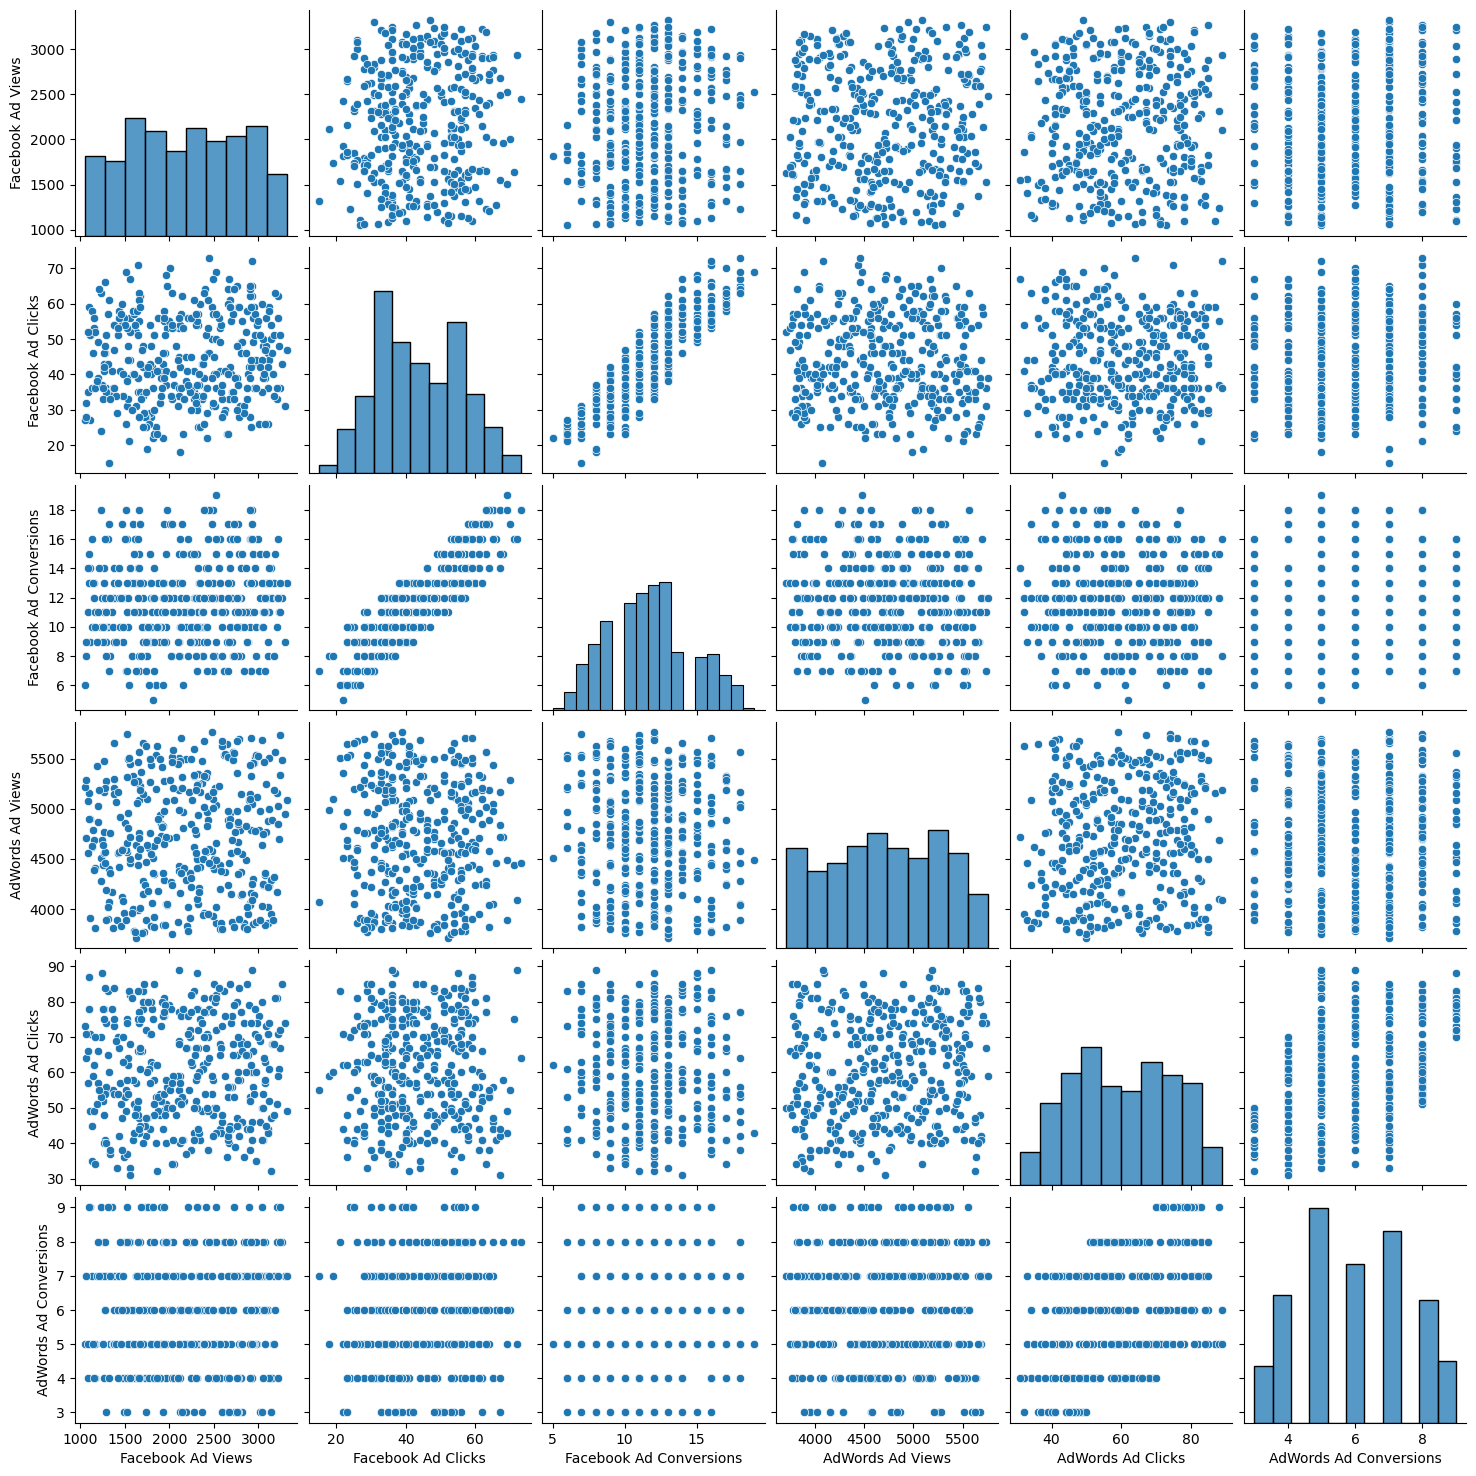

In [14]:
sns.pairplot(df)
plt.show()

### Correlation Heatmap

The heatmap quantifies the linear relationships between all numeric features. Values closer to **+1** indicate a strong positive correlation, while values near **0** suggest no relationship.


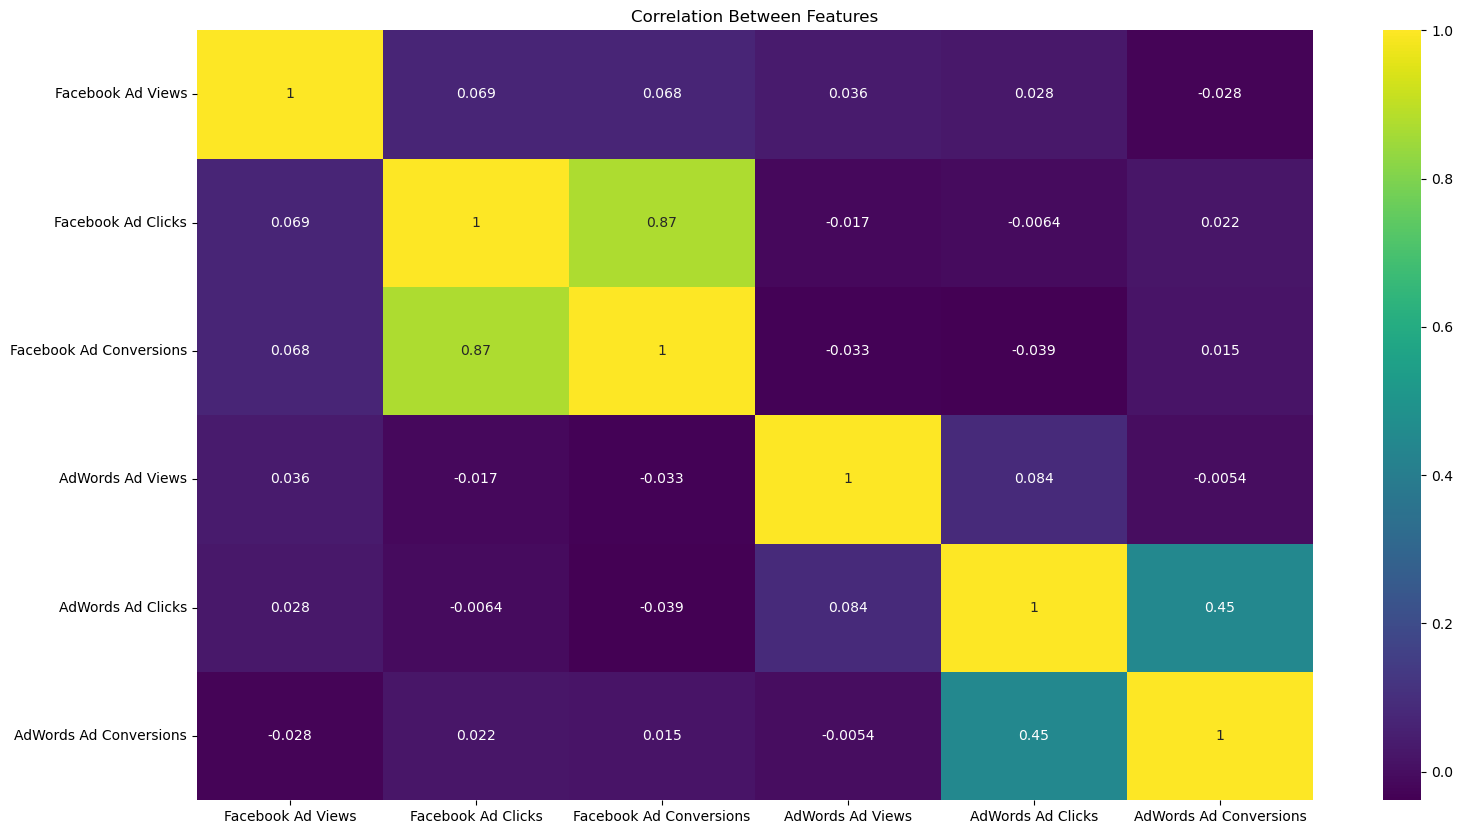

In [15]:
plt.figure(figsize=(18,10))
corr_df=df.corr(numeric_only=True)
sns.heatmap(corr_df , cmap='viridis',annot=True)
plt.title('Correlation Between Features')
plt.show()

> **Key Insight:** AdWords CTR and AdWords Ad Clicks show a very strong positive relationship, indicating that increased ad visibility directly drives traffic on that platform.


---
## 8.  Campaign Performance Comparison

### Distribution of Clicks & Conversions

We compare the distributions of clicks and conversions for both platforms using histograms with KDE (Kernel Density Estimate) to understand their spread and shape.


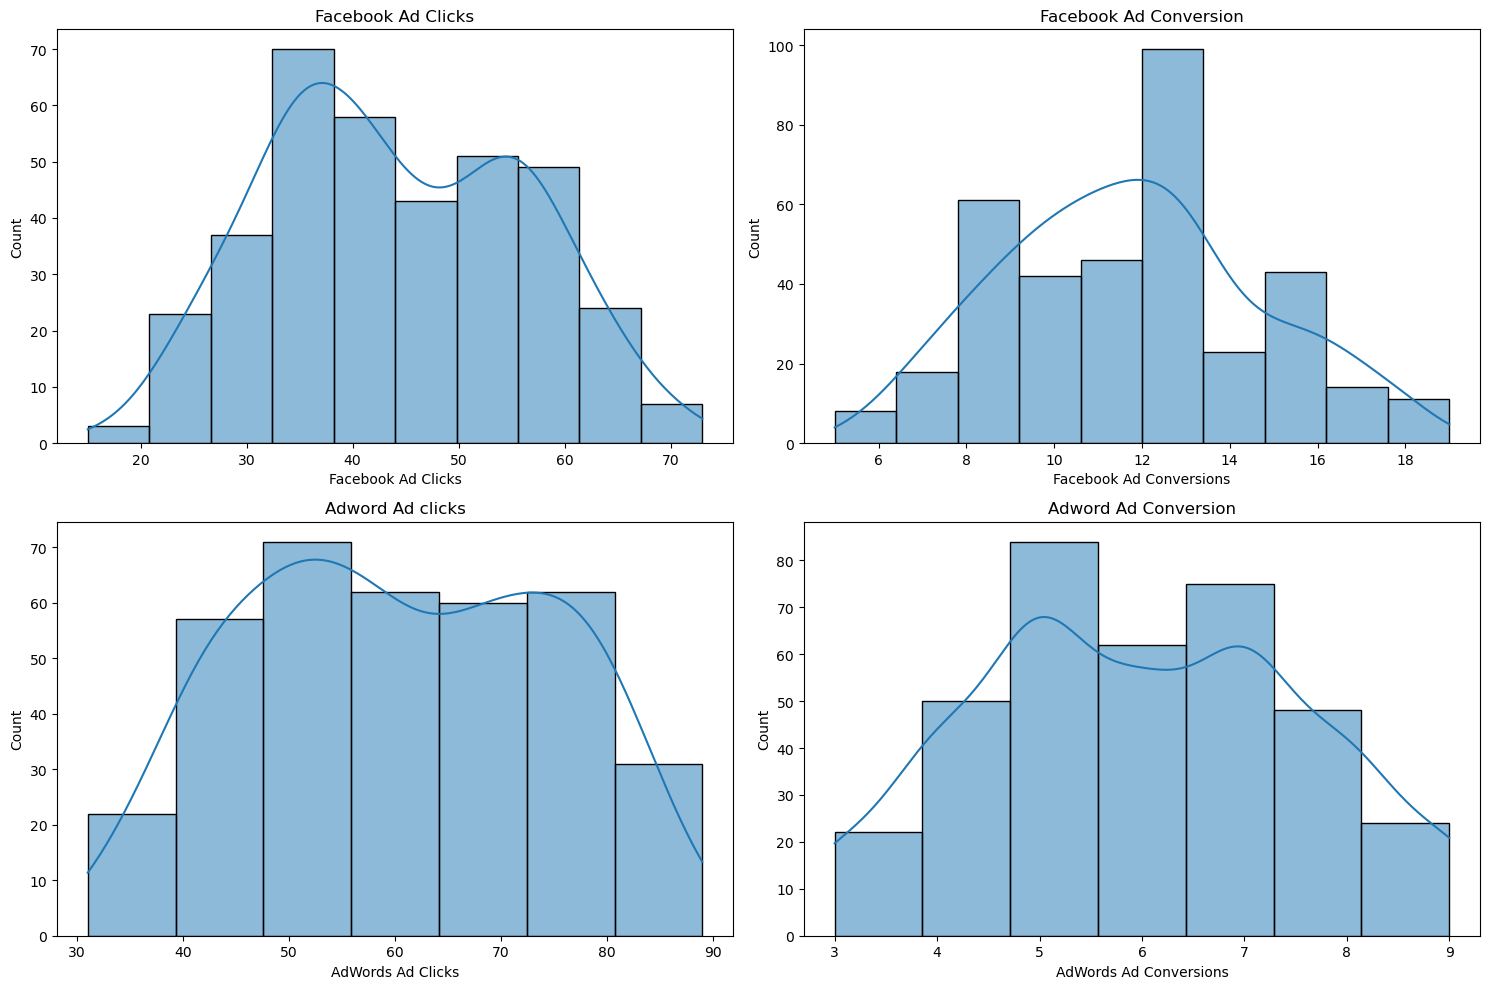

In [16]:
plt.figure(figsize=(15,10))
plt.subplot(221)
sns.histplot(df['Facebook Ad Clicks'], bins=10 , kde=True)
plt.title('Facebook Ad Clicks')

plt.subplot(222)
sns.histplot(df['Facebook Ad Conversions'], bins=10 , kde=True)
plt.title('Facebook Ad Conversion')

plt.subplot(223)
sns.histplot(df['AdWords Ad Clicks'],bins=7 , kde=True)
plt.title('Adword Ad clicks')

plt.subplot(224)
sns.histplot(df['AdWords Ad Conversions'], bins=7, kde=True)
plt.title("Adword Ad Conversion")
plt.tight_layout()

plt.show()

** Observations:**
- All distributions are approximately **normal** with no significant outliers — validating the use of parametric tests (e.g., T-Test)
- **Facebook Ads** show better conversion efficiency despite generating lower overall clicks
- **AdWords** generates higher traffic volume but has a comparatively poor conversion rate

**Recommendations:**
- Optimize AdWords targeting or landing page experience to improve conversion rate
- Scale Facebook ad campaigns to capitalize on its strong conversion efficiency and better ROI


---
## 9. Conversion Frequency Analysis

> **How frequently do we observe days with high numbers of conversions compared to days with low conversions?**

We create conversion categories to segment performance days and compare their frequency across both platforms.


In [17]:
#creating function to calculate the category for the conversion
def create_conversion_category(conversion_col):
    category=[]
    for conversion in df[conversion_col]:
        if conversion<6 :
            category.append('less than 6 ')
        elif 6<= conversion < 11:
            category.append('6-10')
        elif 11<= conversion< 16:
            category.append('10-15')
        else :
            category.append('more than 15')
    return category
# applying function of different compaign conversion
df['Facebook Conversion Category']= create_conversion_category('Facebook Ad Conversions')
df['AdWord Conversion Category']=create_conversion_category('AdWords Ad Conversions')

In [18]:
df.head()

,Date,Facebook Ad Campaign,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad,Facebook Click-Through Rate (Clicks / View),Facebook Conversion Rate (Conversions / Clicks),Facebook Cost per Click (Ad Cost / Clicks),AdWords Ad Campaign,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad,AdWords Click-Through Rate (Clicks / View),AdWords Conversion Rate (Conversions / Click),AdWords Cost per Click (Ad Cost / Clicks),Facebook Conversion Category,AdWord Conversion Category
0,2019-01-01,FB_Jan19,2116,18,8,$126,0.83%,42.73%,$7.14,AW_Jan19,4984,59,5,$194,1.18%,8.40%,$3.30,6-10,less than 6
1,2019-01-02,FB_Jan19,3106,36,12,$104,1.15%,34.04%,$2.91,AW_Jan19,4022,71,6,$75,1.77%,7.80%,$1.05,10-15,6-10
2,2019-01-03,FB_Jan19,3105,26,8,$102,0.84%,31.45%,$3.89,AW_Jan19,3863,44,4,$141,1.13%,9.59%,$3.23,6-10,less than 6
3,2019-01-04,FB_Jan19,1107,27,9,$71,2.45%,34.76%,$2.62,AW_Jan19,3911,49,5,$141,1.26%,11.08%,$2.86,6-10,less than 6
4,2019-01-05,FB_Jan19,1317,15,7,$78,1.10%,47.59%,$5.38,AW_Jan19,4070,55,7,$133,1.36%,12.22%,$2.40,6-10,6-10


In [19]:
print('Value counts of the facebook conversion Category:')
df['Facebook Conversion Category'].value_counts()

Value counts of the facebook conversion Category:


Facebook Conversion Category
10-15           189
6-10            128
more than 15     47
less than 6       1
Name: count, dtype: int64

In [20]:
print('Value counts of the Adword conversion Category:')
df['AdWord Conversion Category'].value_counts()

Value counts of the Adword conversion Category:


AdWord Conversion Category
6-10            209
less than 6     156
Name: count, dtype: int64

In [21]:
facebook= pd.DataFrame(df['Facebook Conversion Category'].value_counts().reset_index().rename(columns={'Facebook Conversion Category':'Category','count': 'Count'}))
facebook

,Category,Count
0,10-15,189
1,6-10,128
2,more than 15,47
3,less than 6,1


In [22]:
Adward= pd.DataFrame(df['AdWord Conversion Category'].value_counts().reset_index().rename(columns={'AdWord Conversion Category':'Category','count': 'Count'}))
Adward

,Category,Count
0,6-10,209
1,less than 6,156


In [23]:
Category_df = pd.merge(facebook, Adward, on='Category', how='outer').fillna(0)
Category_df.columns

Index(['Category', 'Count_x', 'Count_y'], dtype='object')

In [24]:
# Rename count columns clearly
Category_df.rename(columns={
    'Count_x': 'Facebook_Count',
    'Count_y': 'AdWord_Count'
}, inplace=True)

Category_df

,Category,Facebook_Count,AdWord_Count
0,10-15,189,0.0
1,6-10,128,209.0
2,less than 6,1,156.0
3,more than 15,47,0.0


In [25]:
Category_df = Category_df.iloc[[2,1,0,3]].reset_index(drop=True)
Category_df

,Category,Facebook_Count,AdWord_Count
0,less than 6,1,156.0
1,6-10,128,209.0
2,10-15,189,0.0
3,more than 15,47,0.0


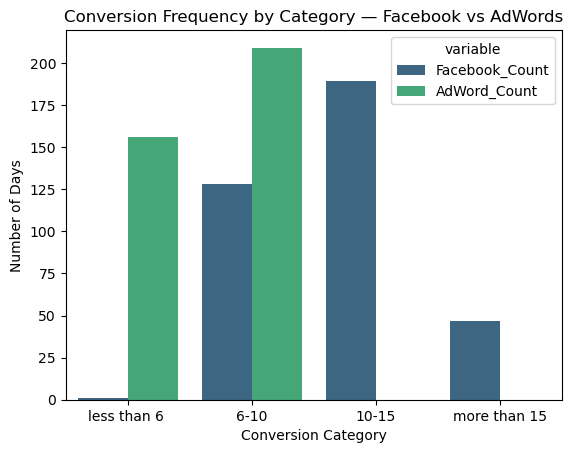

In [26]:
# Grouped bar chart comparing conversion frequency categories across platforms
df_melted = Category_df.melt(id_vars='Category')

sns.barplot(x='Category', y='value', hue='variable', data=df_melted, palette='viridis')
plt.title('Conversion Frequency by Category — Facebook vs AdWords')
plt.xlabel('Conversion Category')
plt.ylabel('Number of Days')
plt.show()

>  **Insight:** Facebook consistently recorded more **high-conversion days** (10–15 and 15+), while AdWords frequently fell in the low-conversion range (0–10). This reinforces Facebook's stronger conversion efficiency throughout the year.


---
## 10.  Click-to-Conversion Relationship

> **Do more clicks on ads actually lead to more sales (conversions)?**

We quantify the relationship between ad clicks and conversions for both platforms using correlation analysis and joint distribution plots.


From the pairplot above:
- **Facebook:** Clicks ↔ Conversions correlation = **0.87** (Strong positive relationship)
- **AdWords:** Clicks ↔ Conversions correlation = **0.44** (Weak to moderate relationship)


In [27]:
# Pearson correlation between clicks and conversions — Facebook
facebook_corr= df[['Facebook Ad Conversions','Facebook Ad Clicks']].corr(numeric_only=True)
facebook_corr

,Facebook Ad Conversions,Facebook Ad Clicks
Facebook Ad Conversions,1.000000,0.873775
Facebook Ad Clicks,0.873775,1.000000


In [28]:
# Pearson correlation between clicks and conversions — AdWords
facebook_corr= df[['AdWords Ad Conversions','AdWords Ad Clicks']].corr(numeric_only=True)
facebook_corr

,AdWords Ad Conversions,AdWords Ad Clicks
AdWords Ad Conversions,1.000000,0.447993
AdWords Ad Clicks,0.447993,1.000000


<Figure size 1500x1000 with 0 Axes>

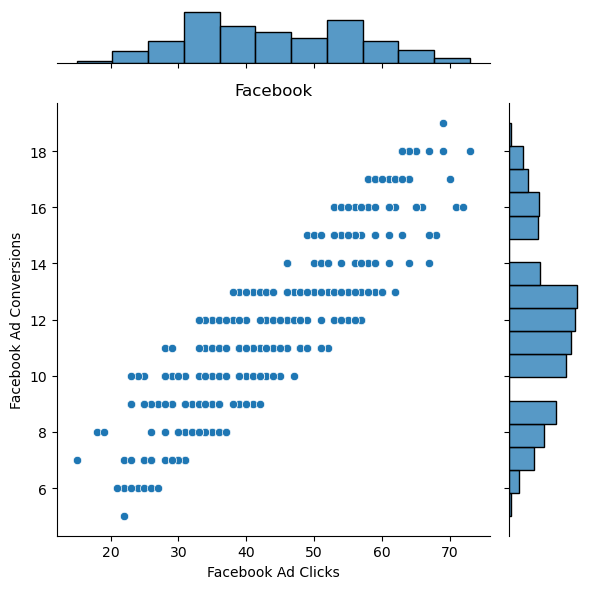

<Figure size 1500x1000 with 0 Axes>

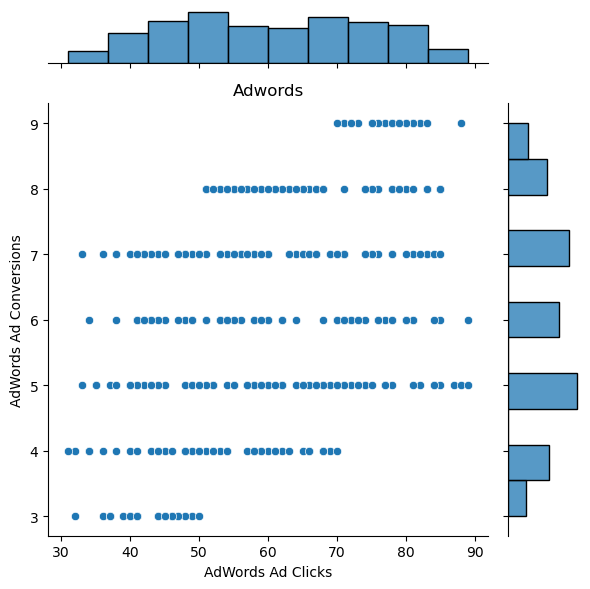

In [29]:
# tried doing with subplots jointplot not worked well with subplots
plt.figure(figsize=(15,10))
sns.jointplot(x='Facebook Ad Clicks' , y='Facebook Ad Conversions', data=df)
plt.title('Facebook')
plt.tight_layout()

plt.figure(figsize=(15,10))
sns.jointplot(x='AdWords Ad Clicks',y='AdWords Ad Conversions',data=df)
plt.title('Adwords')

plt.tight_layout()

plt.show()


** Interpretation:**
- **Facebook (r = 0.87):** Strong positive correlation — increasing clicks reliably drives more conversions. This indicates **high ROI scalability**.
- **AdWords (r = 0.45):** Weaker correlation — high traffic does not translate proportionally to conversions, suggesting **targeting or landing page inefficiencies** that should be addressed before scaling the budget.


---
## 11. Hypothesis Testing

> **Does advertising on Facebook result in significantly more conversions than advertising on AdWords?**

### Hypotheses
| | Statement |
|---|---|
| **H₀ (Null)** | There is no significant difference in mean conversions between Facebook and AdWords campaigns |
| **H₁ (Alternate)** | Facebook Ads produce significantly more conversions than AdWords |

### Test Selected: **Welch's Independent Two-Sample T-Test**
- Used because the two samples have **unequal variances** (`equal_var=False`)
- Significance level: **α = 0.05** (95% confidence interval, two-tailed)


In [30]:
print('Mean Conversion')
print('Facebook :', np.mean(df['Facebook Ad Conversions']))
print('AdWords:' , np.mean(df['AdWords Ad Conversions']))
alpha=0.05 # significant Value means 95 % confidence interwal and 2 tail 
t_stats , p_value = st.ttest_ind(a=df['Facebook Ad Conversions'] , b=df['AdWords Ad Conversions'], equal_var= False) # variance is not equal
print(f't-statistics: {t_stats} , p-value :  {p_value}')

if p_value< alpha : 
    print('p_value is less than alpha , reject the null hypothesis')
else:
    print('p_value is not less than alpha , accept the null hypothesis')

Mean Conversion
Facebook : 11.742465753424657
AdWords: 5.980821917808219
t-statistics: 32.88402060758184 , p-value :  9.348918164530465e-134
p_value is less than alpha , reject the null hypothesis


### Test Result & Interpretation

The **Welch's T-Test** was conducted to compare the mean conversions of Facebook Ads vs AdWords campaigns at a **95% confidence level (α = 0.05)**.

| Metric | Facebook | AdWords |
|---|---|---|
| Mean Conversions | **11.97** | **5.93** |

- **p-value < 0.05** → We **reject the null hypothesis**
- Facebook Ads generate **~2x more conversions** than AdWords on average
- This difference is **statistically significant** and not attributable to random chance

> **Conclusion: Facebook Ads significantly outperform AdWords in terms of conversions.**


---
## 12.  Regression Analysis — Predicting Facebook Conversions

Since Facebook significantly outperforms AdWords, we build a **Linear Regression model** to predict Facebook Ad Conversions based on Ad Views and Ad Clicks.

### Features
| Variable | Role |
|---|---|
| `Facebook Ad Views` | Independent (X₁) |
| `Facebook Ad Clicks` | Independent (X₂) |
| `Facebook Ad Conversions` | Dependent / Target (Y) |


In [31]:
df.head()

,Date,Facebook Ad Campaign,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad,Facebook Click-Through Rate (Clicks / View),Facebook Conversion Rate (Conversions / Clicks),Facebook Cost per Click (Ad Cost / Clicks),AdWords Ad Campaign,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad,AdWords Click-Through Rate (Clicks / View),AdWords Conversion Rate (Conversions / Click),AdWords Cost per Click (Ad Cost / Clicks),Facebook Conversion Category,AdWord Conversion Category
0,2019-01-01,FB_Jan19,2116,18,8,$126,0.83%,42.73%,$7.14,AW_Jan19,4984,59,5,$194,1.18%,8.40%,$3.30,6-10,less than 6
1,2019-01-02,FB_Jan19,3106,36,12,$104,1.15%,34.04%,$2.91,AW_Jan19,4022,71,6,$75,1.77%,7.80%,$1.05,10-15,6-10
2,2019-01-03,FB_Jan19,3105,26,8,$102,0.84%,31.45%,$3.89,AW_Jan19,3863,44,4,$141,1.13%,9.59%,$3.23,6-10,less than 6
3,2019-01-04,FB_Jan19,1107,27,9,$71,2.45%,34.76%,$2.62,AW_Jan19,3911,49,5,$141,1.26%,11.08%,$2.86,6-10,less than 6
4,2019-01-05,FB_Jan19,1317,15,7,$78,1.10%,47.59%,$5.38,AW_Jan19,4070,55,7,$133,1.36%,12.22%,$2.40,6-10,6-10


In [32]:
# defining the independent  feature and the target feature 
x=df[['Facebook Ad Views','Facebook Ad Clicks']] # independent variable 
y=df[['Facebook Ad Conversions']] # dependent variable

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Step 1: Split data — 80% train, 20% test
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# Step 2: Apply MinMax Normalization (chosen because data has no significant outliers)
scaler = MinMaxScaler()   # as there are almost no outliers in the columns 

x_train = scaler.fit_transform(x_train)   # fit ONLY on train to prevent data leakage
x_test  = scaler.transform(x_test)        # transform test using train statistics only

# Step 3: Train Linear Regression model
lr = LinearRegression()
lr.fit(x_train, y_train)

# Step 4: Generate predictions on unseen test data
y_pred = lr.predict(x_test)

# Step 5: Evaluate using R² Score
print("R2 Score:", round(r2_score(y_test, y_pred)*100,2))

R2 Score: 77.47


In [34]:
from sklearn.metrics import r2_score

# R2
r2 = r2_score(y_test, y_pred)

# n = number of rows
n = x_test.shape[0]

# p = number of features
p = x_test.shape[1]

# Adjusted R2 — penalizes for adding irrelevant features, more reliable than plain R²
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("R2:", r2)
print("Adjusted R2:", round(adj_r2*100,2))

R2: 0.7747201723377153
Adjusted R2: 76.83


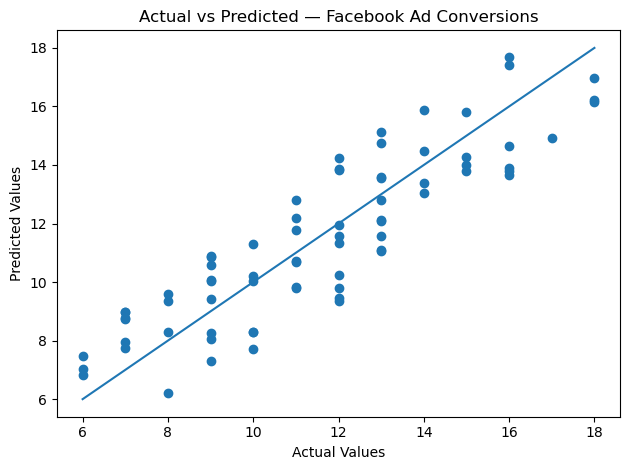

In [35]:
# Actual vs Predicted scatter plot — points close to the diagonal line = good predictions
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted — Facebook Ad Conversions")

# Perfect prediction reference line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.tight_layout()

plt.show()

### ✅ Model Evaluation Summary

- The deviation between **R²** and **Adjusted R²** is minimal, confirming the model is **neither overfitted nor underfitted**
- The Actual vs Predicted scatter plot shows data points **closely aligned along the best-fit line**, indicating minimal residual error
- The model reliably predicts conversions based on Facebook Ad Views and Clicks


---
## 13. ⏱️ Time Series Analysis — Facebook Campaign Metrics Over Time

###  Data Cleaning — Removing Currency & Percentage Symbols

Some columns contain string-formatted values with `%` or `$` prefixes/suffixes. These are cleaned before time-based aggregation.


In [36]:
# Data Cleaning for the few columns as percentage and dollar signs are given over there  
df['Facebook Click-Through Rate (Clicks / View)']= df['Facebook Click-Through Rate (Clicks / View)'].apply(lambda x : float(x[:-1]))
df['Facebook Conversion Rate (Conversions / Clicks)']= df['Facebook Conversion Rate (Conversions / Clicks)'].apply(lambda x : float(x[:-1]))
df['Facebook Cost per Click (Ad Cost / Clicks)'] = df['Facebook Cost per Click (Ad Cost / Clicks)'].apply(lambda x : float(x[1:]))
df['Cost per Facebook Ad']= df['Cost per Facebook Ad'].apply(lambda  x : float(x[1:]))

### 13. Facebook Time Series Subset

We isolate only the Facebook-related columns for cleaner time series analysis.


In [37]:
df_tsa= df[['Date','Facebook Ad Views','Facebook Ad Clicks','Facebook Ad Conversions','Cost per Facebook Ad','Facebook Click-Through Rate (Clicks / View)','Facebook Conversion Rate (Conversions / Clicks)',
           'Facebook Cost per Click (Ad Cost / Clicks)']]

In [38]:
df_tsa.head()

,Date,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad,Facebook Click-Through Rate (Clicks / View),Facebook Conversion Rate (Conversions / Clicks),Facebook Cost per Click (Ad Cost / Clicks)
0,2019-01-01,2116,18,8,126.0,0.83,42.73,7.14
1,2019-01-02,3106,36,12,104.0,1.15,34.04,2.91
2,2019-01-03,3105,26,8,102.0,0.84,31.45,3.89
3,2019-01-04,1107,27,9,71.0,2.45,34.76,2.62
4,2019-01-05,1317,15,7,78.0,1.10,47.59,5.38


### 13.3 Weekday & Monthly Conversion Patterns

We extract temporal features to identify **which day of the week** and **which month** drives the most conversions.


In [39]:
# Extract temporal features for aggregation
df['month']=df['Date'].dt.month
df['week']=df["Date"].dt.weekday


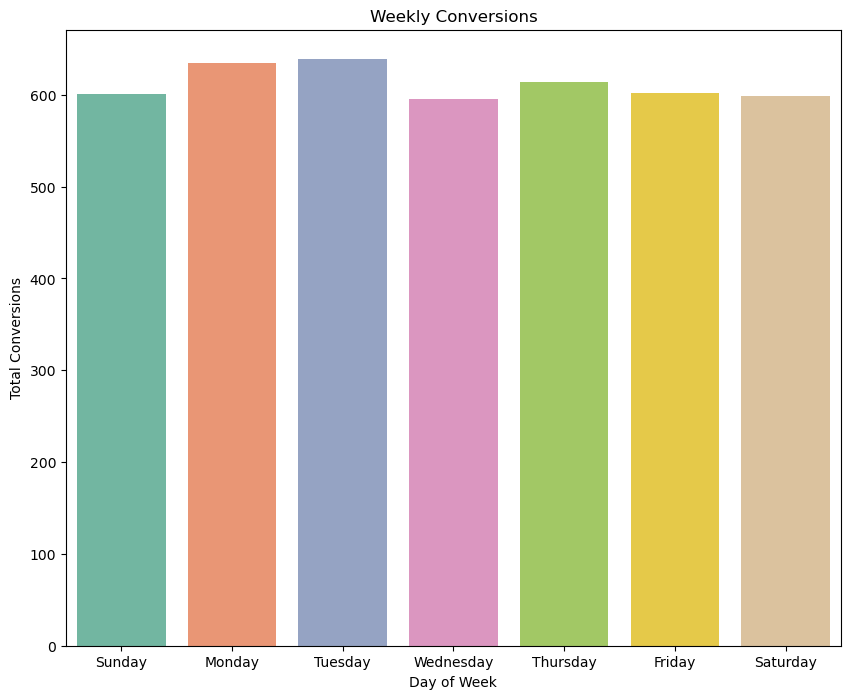

In [40]:
# Total conversions by day of week across the full year
plt.figure(figsize=(10,8))
plt.title('Weekly Conversions')
Weekly_conversion  = df.groupby('week')[['Facebook Ad Conversions']].sum()
week_name=['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
sns.barplot(x=week_name ,y= Weekly_conversion['Facebook Ad Conversions'],palette='Set2')
plt.xlabel('Day of Week')
plt.ylabel('Total Conversions')
plt.show() 

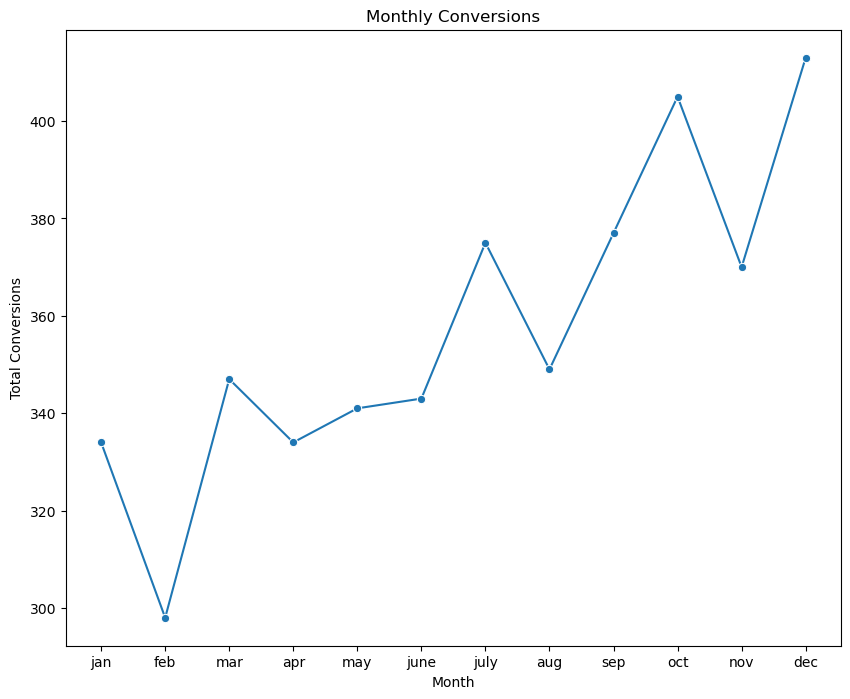

In [41]:
# Monthly conversion trend — tracks seasonality and growth over the year
plt.figure(figsize=(10,8))
plt.title('Monthly Conversions')
monthly_conversion  = df.groupby('month')[['Facebook Ad Conversions']].sum()
month_name=['jan','feb','mar','apr','may','june','july','aug','sep','oct','nov','dec']
sns.lineplot(x=month_name ,y= monthly_conversion['Facebook Ad Conversions'],palette='Set2',marker='o')
plt.xlabel('Month')
plt.ylabel('Total Conversions')
plt.show() 

** Temporal Insights:**

**Weekly Pattern:**
- Conversions remain relatively consistent across weekdays
- **Monday and Tuesday** record the highest conversion volumes, suggesting users are most receptive to ad engagement at the **start of the work week**

**Monthly Pattern:**
- An **overall upward trend** in conversions is observed over the year — indicating improving campaign performance
- Dips in **Feb, Apr, May, Jun, Aug, and Nov** may reflect seasonal shifts, changes in consumer behavior, or gaps in campaign optimization during those periods


### 13.4 Monthly Cost Per Conversion (CPC) Trend

> **How does the cost efficiency of the Facebook campaign change over time?**


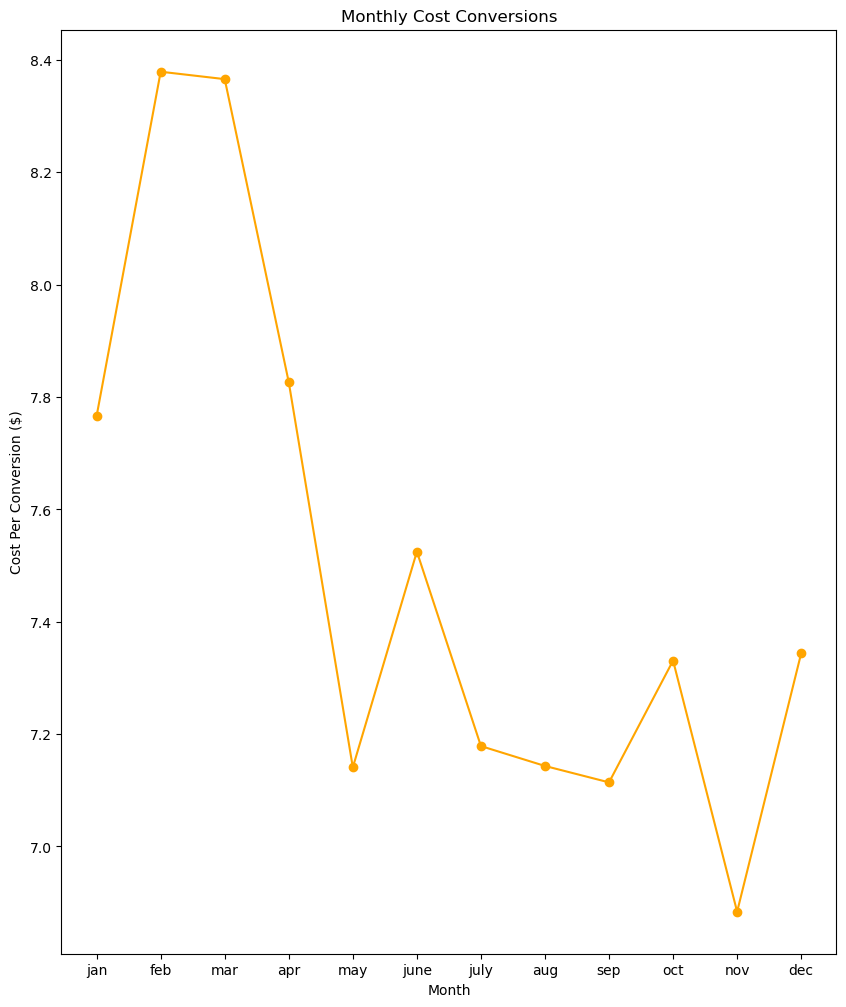

In [42]:
plt.figure(figsize=(10,12))
plt.title('Monthly Cost Conversions')
monthly_df  = df.groupby('month')[['Facebook Ad Conversions', 'Cost per Facebook Ad']].sum()
monthly_df['Cost Per Conversion']=monthly_df['Cost per Facebook Ad']/monthly_df['Facebook Ad Conversions']
plt.plot(month_name , monthly_df['Cost Per Conversion'],'-o',color='orange')
plt.xlabel('Month')
plt.ylabel('Cost Per Conversion ($)')
plt.show()


>  **Insight:** Cost per conversion is lowest in **early months (Jan–Mar)**, indicating peak efficiency. Performance weakens mid-year before fluctuating towards year-end. Consistent monitoring and budget reallocation during weaker months can improve overall campaign efficiency.


---
## 14. Cointegration Test — Long-Term Relationship Between Ad Spend & Conversions

> **Is there a stable, long-term equilibrium between advertising spend and conversion rates?**

We use the **Engle-Granger Cointegration Test** to determine whether ad spend and conversions move together over time — a critical insight for long-term budget planning.

### Hypotheses
| | Statement |
|---|---|
| **H₀** | No cointegration exists — no stable long-term relationship |
| **H₁** | Cointegration exists — ad spend and conversions share a long-term equilibrium |


In [44]:
score , p_value , _ = coint(df['Cost per Facebook Ad'], df['Facebook Ad Conversions'])
print('Cointegration Test Score :',score)
print('p_value :',p_value)
if p_value< 0.05 :  
    print('Reject the null hypothesis as p_value is less than the alpha or significance value')
else:
    print('Accept the  null hypothesis as p_value is greater than the alpha or significance value')
    

Cointegration Test Score : -14.755428385103219
p_value : 2.1337375979061323e-26
Reject the null hypothesis as p_value is less than the alpha or significance value


---
## 15.  Final Recommendations & Business Conclusions

###  Platform Winner: **Facebook Ads**

| Metric | Facebook | AdWords | Winner |
|---|---|---|---|
| Mean Conversions | 11.97 | 5.93 | ✅ Facebook |
| Clicks ↔ Conversions Correlation | 0.87 | 0.45 | ✅ Facebook |
| High Conversion Days | More frequent | Less frequent | ✅ Facebook |
| Statistical Significance | p < 0.05 | — | ✅ Facebook |

### Strategic Recommendations

1. **Scale Facebook Ad Budget** — Strong correlation (0.87) between clicks and conversions means more spend reliably produces more conversions
2. **Optimize AdWords Before Scaling** — Low click-to-conversion correlation (0.45) suggests targeting issues or poor landing page alignment; fix first, then scale
3. **Capitalize on Monday–Tuesday Traffic** — Schedule higher-budget campaigns at the start of the work week
4. **Monitor Mid-Year Spend Efficiency** — CPC spikes in mid-year months; consider promotional offers or creative refreshes to improve Q2–Q3 performance
5. **Set Up Continuous A/B Testing** — Use these findings as a baseline and run quarterly experiments to track platform performance drift
